In [30]:
import pandas as pd
import talib
import matplotlib.pyplot as plt
import yfinance as yf
import numpy as np

In [31]:
df = pd.read_csv('../data/TSLA_historical_data.csv')
df['Date'] = pd.to_datetime(df['Date'])
df.sort_values('Date', inplace=True)
df.set_index('Date', inplace=True)
print(df.head())

                Open      High       Low     Close  Adj Close     Volume  \
Date                                                                       
2010-06-29  1.266667  1.666667  1.169333  1.592667   1.592667  281494500   
2010-06-30  1.719333  2.028000  1.553333  1.588667   1.588667  257806500   
2010-07-01  1.666667  1.728000  1.351333  1.464000   1.464000  123282000   
2010-07-02  1.533333  1.540000  1.247333  1.280000   1.280000   77097000   
2010-07-06  1.333333  1.333333  1.055333  1.074000   1.074000  103003500   

            Dividends  Stock Splits  
Date                                 
2010-06-29        0.0           0.0  
2010-06-30        0.0           0.0  
2010-07-01        0.0           0.0  
2010-07-02        0.0           0.0  
2010-07-06        0.0           0.0  


In [32]:
# --- Simple Moving Averages (SMA) ---
df['SMA_20'] = talib.SMA(df['Close'], timeperiod=20)
df['SMA_50'] = talib.SMA(df['Close'], timeperiod=50)

# --- Relative Strength Index (RSI) ---
df['RSI_14'] = talib.RSI(df['Close'], timeperiod=14)

# --- MACD (Moving Average Convergence Divergence) ---
df['MACD'], df['MACD_Signal'], df['MACD_Hist'] = talib.MACD(
    df['Close'], fastperiod=12, slowperiod=26, signalperiod=9
)

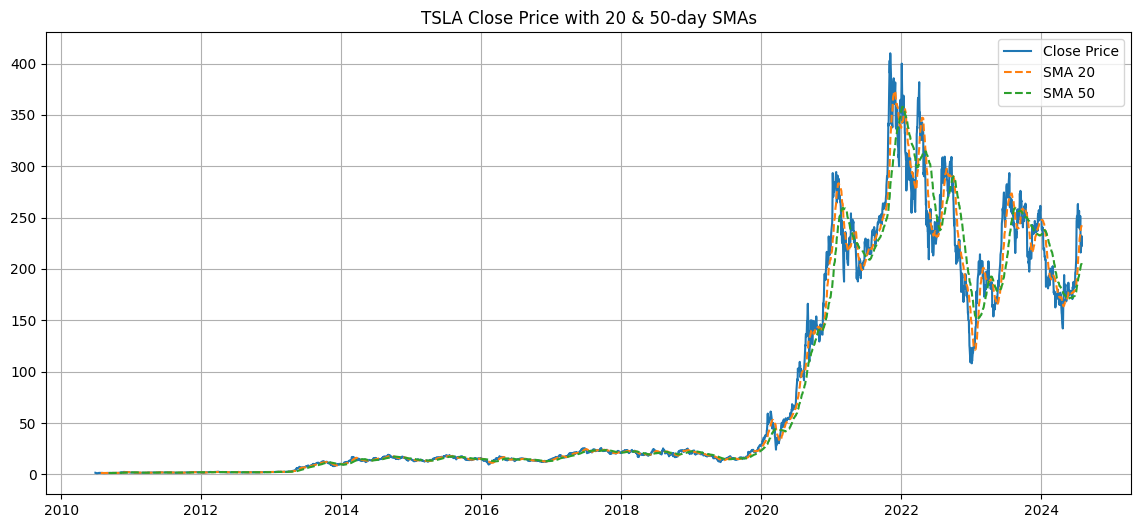

In [33]:
# Plot Close Price with SMA
plt.figure(figsize=(14, 6))
plt.plot(df.index, df['Close'], label='Close Price', linewidth=1.5)
plt.plot(df.index, df['SMA_20'], label='SMA 20', linestyle='--')
plt.plot(df.index, df['SMA_50'], label='SMA 50', linestyle='--')
plt.title('TSLA Close Price with 20 & 50-day SMAs')
plt.legend()
plt.grid(True)
plt.show()


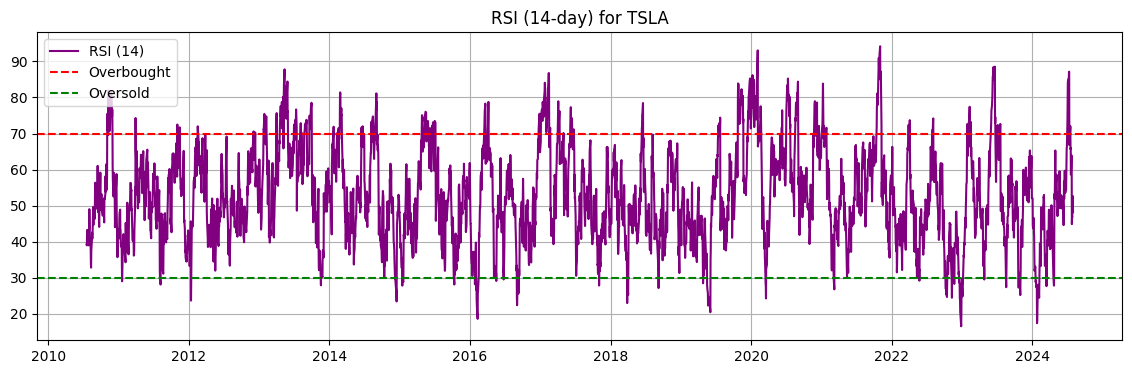

In [34]:
# RSI
plt.figure(figsize=(14, 4))
plt.plot(df.index, df['RSI_14'], label='RSI (14)', color='purple')
plt.axhline(70, linestyle='--', color='red', label='Overbought')
plt.axhline(30, linestyle='--', color='green', label='Oversold')
plt.title('RSI (14-day) for TSLA')
plt.legend()
plt.grid(True)
plt.show()


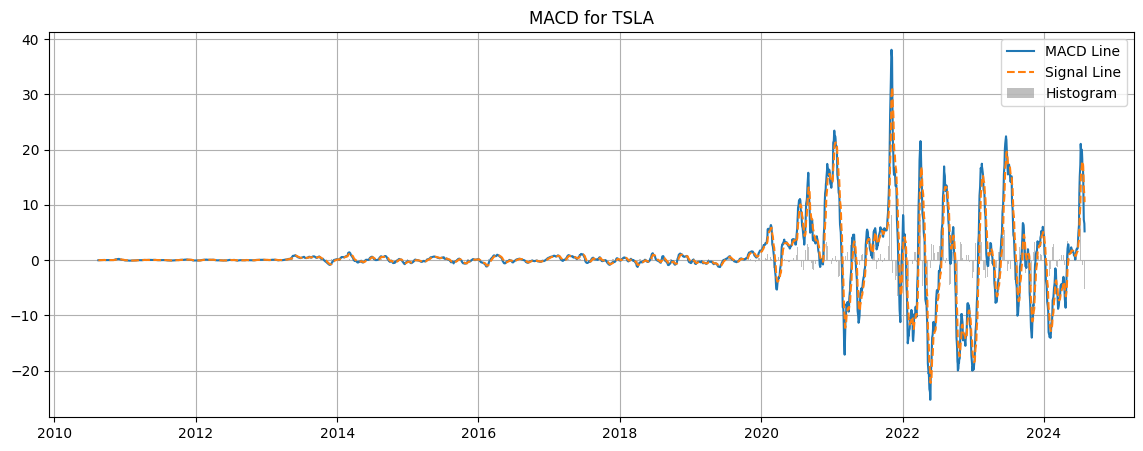

In [35]:
# MACD
plt.figure(figsize=(14, 5))
plt.plot(df.index, df['MACD'], label='MACD Line')
plt.plot(df.index, df['MACD_Signal'], label='Signal Line', linestyle='--')
plt.bar(df.index, df['MACD_Hist'], label='Histogram', color='gray', alpha=0.5)
plt.title('MACD for TSLA')
plt.legend()
plt.grid(True)
plt.show()


Annual Return: 52.65%
Annual Volatility: 56.61%
Sharpe Ratio: 0.93


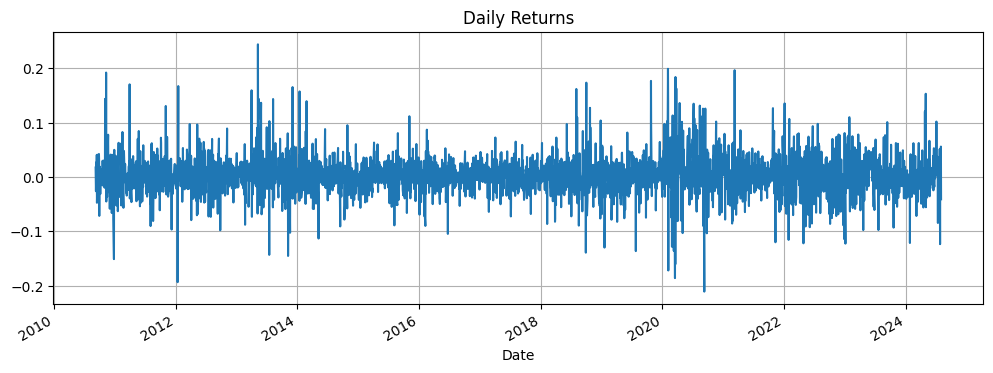

In [36]:
# Use 'Adj Close' for return calculation
df['Daily Return'] = df['Adj Close'].pct_change()
df.dropna(inplace=True)

# Compute metrics
annual_return = df['Daily Return'].mean() * 252
annual_volatility = df['Daily Return'].std() * (252 ** 0.5)
sharpe_ratio = annual_return / annual_volatility

print(f"Annual Return: {annual_return:.2%}")
print(f"Annual Volatility: {annual_volatility:.2%}")
print(f"Sharpe Ratio: {sharpe_ratio:.2f}")

# Plot daily return
df['Daily Return'].plot(title='Daily Returns', figsize=(12, 4))
plt.grid()
plt.show()
